In [22]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict

In [23]:
## define state 
class BMIState(TypedDict):
    weight_kg : float
    height_m : float
    bmi : float
    category : str


In [24]:
def bmi_calculator(state:BMIState)->BMIState:
    weight=state['weight_kg']
    height=state['height_m']
    bmi=weight/(height**2)

    state['bmi']=round(bmi,2)
    return state

In [25]:
def bmi_label(state: BMIState)->BMIState:
    bmi=state['bmi']

    if   18 <= bmi<=22:
        state['category']='normal'
    if bmi<18 :
        state['category']='underweight'
    if bmi>22:
        state['category']='overweight'


    return state          

In [26]:
## define workflow  graph

graph= StateGraph(BMIState)
## bmi_calculator node

graph.add_node('bmi_calculator', bmi_calculator)
graph.add_node('bmi_label',bmi_label)

## add edges

graph.add_edge(START,'bmi_calculator')
graph.add_edge('bmi_calculator','bmi_label')
graph.add_edge('bmi_label',END)


##compile the graph
workflow=graph.compile()





In [27]:
## execute the workflow 

result= workflow.invoke({'weight_kg':56,'height_m':1.8})
print(result)

{'weight_kg': 56, 'height_m': 1.8, 'bmi': 17.28, 'category': 'underweight'}


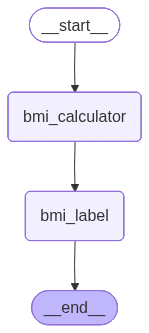

In [28]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png()) ## workflow graph ...